(cifar10-resnet18-silu)=
# Cifar10 上的 ReNet18(SiLU)

本文主要介绍在 cifar10 的试验 resnet18 的性能。

导入一些必要包：

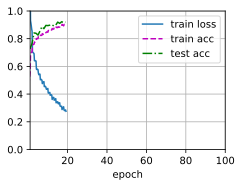

In [9]:
import logging
import torch
from torch import nn
from torchvision.models import resnet18, ResNet18_Weights
from torch_book.vision.classifier import Classifier, evaluate_accuracy
from torch_book.datasets.cifar10 import Cifar10
torch.cuda.empty_cache() # 清空 GPU 缓存
from torch_book.transforms.cutout import Cutout


logging.basicConfig(filename='logs/debug-graph-silu.log',
                    filemode="a",
                    format='%(asctime)s|%(levelname)s|%(name)s->%(funcName)s@%(message)s',
                    level=logging.INFO)

num_epochs = 100
model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.conv1 = nn.Conv2d(model.conv1.in_channels,
                        model.conv1.out_channels,
                        3, 1, 1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(model.fc.in_features, 10)
data = Cifar10(batch_size = 32, cutout=Cutout(1, 16), num_workers=8)
train_iter = data.train_loader()
test_iter = data.val_loader()
classifier = Classifier(model, train_iter, test_iter, device=torch.device("cuda:0"))
classifier.prepare_optimizer(lr=0.0142857, momentum=0.857142,
                             weight_decay=0.000857142)
classifier.prepare_scheduler(lr_period=2, lr_decay=0.857142)
classifier.prepare_animator(num_epochs)
classifier.fit(num_epochs)

In [ ]:
test_acc = evaluate_accuracy(classifier.mod, classifier.test_iter, device=torch.device("cuda:0"))
test_acc

In [ ]:
torch.save(classifier.mod.state_dict(),
           'params/resnet18_cifar10_relu_cutout.h5')

## 性能度量

In [ ]:
from torch.profiler import profile, record_function, ProfilerActivity
inputs = torch.randn(5, 3, 32, 32).type(torch.float32).cuda()       
with profile(activities=[ProfilerActivity.CPU, 
                         ProfilerActivity.CUDA], 
             record_shapes=True) as prof:
    with record_function("model_inference"):
        classifier.mod(inputs)
print(prof.key_averages().table(sort_by="cuda_time_total", row_limit=10))